In [4]:
import helpers
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1.0,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2.0,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3.0,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4.0,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5.0,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [18]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
case = CavityCase(8)

case.ds.U.sel(y=0.5, method='nearest')
# case = CavityCase(7)
# case_1.plot()
case.snap_times, case.snapshots
# case_1.animate(saveFig=True)
case.v_horizontal_slice()
psi = case.psi
# print(psi.min(), psi.max())
# plt.contourf(case.X, case.Y, psi, levels=20)
# plt.colorbar()
# plt.show()
# case.vortex_strengths
# case.plot_psi()
case.animate(step=5, title="Re=1000, N=64", saveFig=True)

In [ ]:
CaseManager = helpers.CaseManager

In [ ]:
case_df.iloc[[1,2,3,4,5]]
manager = CaseManager([1,2,3,4,5])
# uds_primary = manager.collect_vortex_strengths()

manager.collect_vortex_strengths()
manager2 = CaseManager([6,7,8,9])


,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URF,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
1,2.0,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3.0,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4.0,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5.0,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600
5,6.0,EFSM,1,QUICK,1000,16,0.062500,0.062500,0.1000,1.600,-1.0,0.1500,675.0,0.433787,C1,25.000000,50.0,13.5000,0.007230


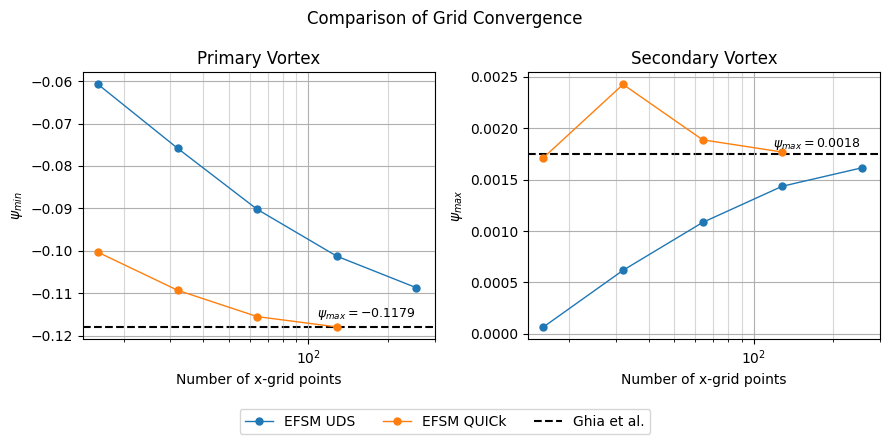

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
uds_primary = manager.collect_vortex_strengths()
labels = ["EFSM UDS","EFSM QUICk"]
groups=[manager, manager2]

for group,label in zip(groups, labels):
    primary, secondary = group.collect_vortex_strengths()
    psi_min = primary["psi"]
    psi_max = secondary["psi"]
    ms,lw =5, 1
    axes[0].plot(primary["N"],primary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
    axes[1].plot(secondary["N"], secondary["psi"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
ghia = [-0.117929, 0.00175102]
for ax, title, y_label,ref_psi in zip(axes, ["Primary Vortex", "Secondary Vortex"], [r"$\psi_{min}$", r"$\psi_{max}$"], ghia):
     ax.set_title(title)      
     ax.set_xlabel("Number of x-grid points")
     ax.grid(which='major')
     ax.grid(which='minor', alpha=0.5)
     ax.set_ylabel(y_label)
     ax.axhline(y=ref_psi, color='black', linestyle='--', label='Ghia et al.',zorder=0)
     ax.annotate(rf'$\psi_{{max}}={ref_psi:.4f}$', 
                    xy=(254, ref_psi+0.01*abs(ref_psi)), ha='right', va='bottom',
                    fontsize=9,
                    color='black')
     ax.set_xscale('log')
     ax.set_xlim(14, 300)
fig.suptitle("Comparison of Grid Convergence")
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend( handles,labels,ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0))

In [ ]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
class CaseManager:
    ghia_psi_min, ghia_psi_max = -0.117929, 0.00175102
    def __init__(self, case_numbers, root_folder="../case_data/"):
        self.cases = {}
        for num in case_numbers:
            case = CavityCase(num)  # Your existing case class
            self.cases[num] = case

    def collect_vortex_strengths(self):
        primary_records = []
        secondary_records = []
        for case_id, case in self.cases.items():
            # Get the two DataFrames from vortex_strengths
            primary_df, secondary_df = case.vortex_strengths
            # Add metadata to each
            for df in [primary_df, secondary_df]:
                df["case"] = case_id
                df["RE"] = case.RE
                df["scheme"] = case.solution_method
                df["N"] = case.N
                # Add any other relevant metadata here
            primary_records.append(primary_df)
            secondary_records.append(secondary_df)

        # Concatenate separately
        primary_all = pd.concat(primary_records, ignore_index=True)
        secondary_all = pd.concat(secondary_records, ignore_index=True)

        return primary_all, secondary_all
    def compare_convergence(self):
        # For example, combine convergence residuals from all cases
        import pandas as pd
        records = []
        for case_id, case in self.cases.items():
            df = case.res_df.copy()
            df["case"] = case_id
            df["RE"] = case.RE
            records.append(df)
        return pd.concat(records, ignore_index=True)
    def compare_meta(self):
        meta_dicts = []
        for case_id, case in self.cases.items():
            meta_dicts.append(case.meta)
        meta_df = pd.DataFrame(meta_dicts)
        return pd.DataFrame(meta_dicts, index=self.cases.keys())
    def compare_time(self,time=2.5):
        it_lst = 2.5/self.compare_meta()["DT"]
        snapshot_lst=[]
        dict_lst = []
        for case_id, case in self.cases.items():
            target = it_lst[case_id]

            i, closest_val = min(
                enumerate(case.snap_times),
                key=lambda x: abs(x[1] - target)
            )

            snapshot_lst.append(case.snapshots[i])
            case.compute_streamfunction(time=closest_val).min()
            dict_lst.append({
                "case": case_id,
                "DT": case.meta["DT"],
                "IT": int(target),
                "psi_min": case.compute_streamfunction(time=closest_val).min(),
            })
        return pd.DataFrame(dict_lst)
# manager3 = CaseManager([16,17,18,19,20])
# manager3.compare_time()

In [ ]:
manager4 = CaseManager([21,22,23,24,25])
manager4.compare_convergence()

,IT,N,RESORM,RESORU,RESORV,case,RE
0,20,474,0.000100,3.183133,1.431998,21,1000.0
1,40,215,0.000100,1.955040,1.089841,21,1000.0
2,60,222,0.000100,1.521331,1.059098,21,1000.0
3,80,335,0.000100,1.336244,1.071807,21,1000.0
4,100,395,0.000100,1.286469,1.082326,21,1000.0
...,...,...,...,...,...,...,...
5890,63440,1,0.000002,0.000469,0.000505,25,1000.0
5891,63460,1,0.000002,0.000468,0.000504,25,1000.0
5892,63480,1,0.000002,0.000467,0.000503,25,1000.0
5893,63500,1,0.000002,0.000467,0.000500,25,1000.0


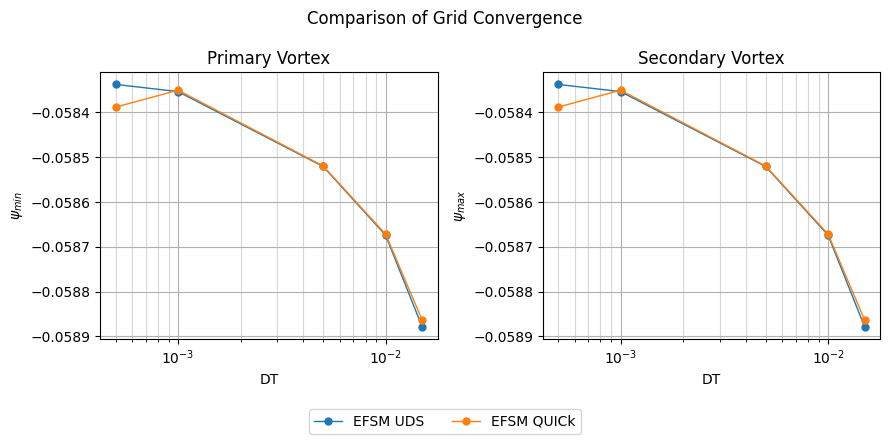

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
uds_primary = manager.collect_vortex_strengths()
labels = ["EFSM UDS","EFSM QUICk"]
manager3 = CaseManager([16,17,18,19,20])
manager3 = CaseManager([16,17,18,19,20])
groups=[CaseManager([16,17,18,19,20]), CaseManager([21,22,23,24,25])]

for group,label in zip(groups, labels):
    primary, secondary = group.collect_vortex_strengths()
    compare_time_df = group.compare_time()

    psi_min = primary["psi"]
    psi_max = secondary["psi"]
    ms,lw =5, 1
    axes[0].plot(compare_time_df["DT"],compare_time_df["psi_min"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
    axes[1].plot(compare_time_df["DT"], compare_time_df["psi_min"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
ghia = [-0.117929, 0.00175102]
for ax, title, y_label,ref_psi in zip(axes, ["Primary Vortex", "Secondary Vortex"], [r"$\psi_{min}$", r"$\psi_{max}$"], ghia):
     ax.set_title(title)      
     ax.set_xlabel("DT")
     ax.grid(which='major')
     ax.grid(which='minor', alpha=0.5)
     ax.set_ylabel(y_label)
    #  ax.axhline(y=ref_psi, color='black', linestyle='--', label='Ghia et al.',zorder=0)
     ax.annotate(rf'$\psi_{{max}}={ref_psi:.4f}$', 
                    xy=(254, ref_psi+0.01*abs(ref_psi)), ha='right', va='bottom',
                    fontsize=9,
                    color='black')
     ax.set_xscale('log')

fig.suptitle("Comparison of Grid Convergence")
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend( handles,labels,ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0))

In [ ]:
importlib.reload(helpers)
CaseManager = helpers.CaseManager
groups=[CaseManager([16,17,18,19,20]), CaseManager([21,22,23,24,25])]
groups[0].compare_meta()

      sum_N  total_outer_iterations  total_inner_iterations  \
case                                                          
16    14547                    4202                  290940   
17    10979                    5552                  219580   
18     6445                    9328                  128900   
19     2668                   35260                   53360   
20     3617                   63517                   72340   

      avg_inner_per_outer  
case                       
16              69.238458  
17              39.549712  
18              13.818611  
19               1.513330  
20               1.138908  


,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
16,fs,quick,1000.0,64,1,0.0150,61.849926,4202,14547,4202,290940,69.238458
17,fs,quick,1000.0,64,1,0.0100,48.560310,5552,10979,5552,219580,39.549712
18,fs,quick,1000.0,64,1,0.0050,34.663536,9328,6445,9328,128900,13.818611
19,fs,quick,1000.0,64,1,0.0010,47.817623,35260,2668,35260,53360,1.513330
20,fs,quick,1000.0,64,1,0.0005,76.141212,63517,3617,63517,72340,1.138908


In [ ]:
df= group.compare_convergence()
df.groupby("case")["N"].sum().reset_index(name="total_inner_iterations")


,case,total_inner_iterations
0,21,16624
1,22,5746
2,23,5423
3,24,2270
4,25,3482


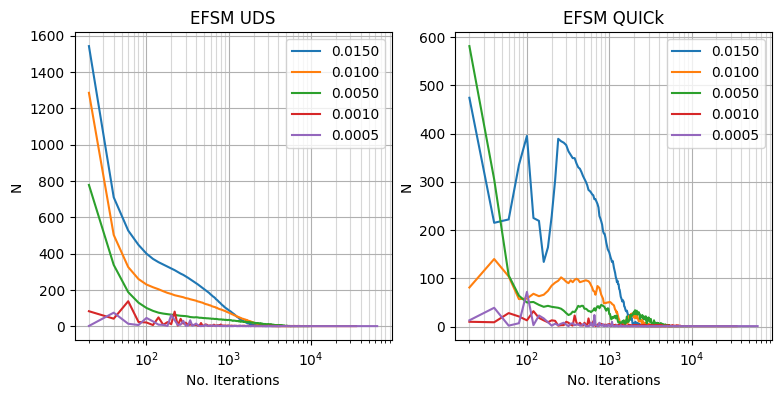

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

labels = ["EFSM UDS","EFSM QUICk"]
for i,(group,label) in enumerate(zip(groups, labels)):
    convergence_df =  group.compare_convergence()
    ax = axes[i]
    for case_id, case in group.compare_convergence().groupby("case"):
        ax.plot(case["IT"], case["N"], label = f"{group.cases[case_id].meta["DT"]:.4f}")
        ax.set_xscale('log')
    ax.set_xlabel("No. Iterations")
    ax.set_ylabel("N")
    ax.set_title(label)
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend()

      sum_N  total_outer_iterations  total_inner_iterations  \
case                                                          
16    14547                    4202                  290940   
17    10979                    5552                  219580   
18     6445                    9328                  128900   
19     2668                   35260                   53360   
20     3617                   63517                   72340   

      avg_inner_per_outer  
case                       
16              69.238458  
17              39.549712  
18              13.818611  
19               1.513330  
20               1.138908  
      sum_N  total_outer_iterations  total_inner_iterations  \
case                                                          
21    16624                    4190                  332480   
22     5746                    5551                  114920   
23     5423                    9339                  108460   
24     2270                   35262            

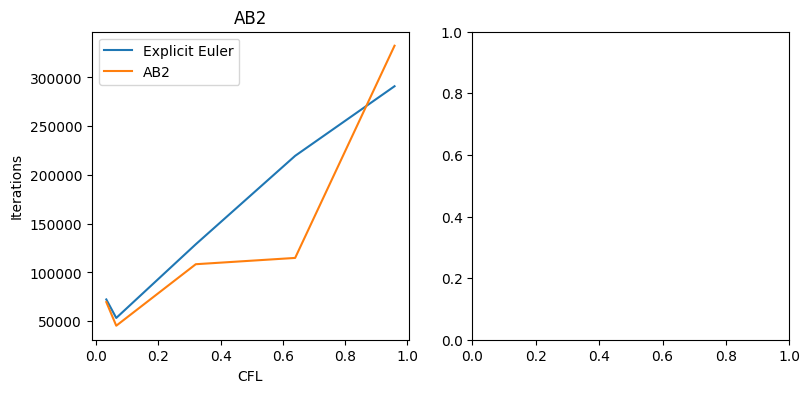

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

labels = ["Explicit Euler","AB2"]
for i,(group,label) in enumerate(zip(groups, labels)):
    meta_df =  group.compare_meta()
    ax = axes[0]
    DX = 1/meta_df['N']
    CFL=meta_df['DT']/DX
    ax.plot(CFL, meta_df["total_inner_iterations"], label=label)

    ax.set_xlabel("CFL")
    ax.set_ylabel("Iterations")
    ax.set_title(label)
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    ax.legend()

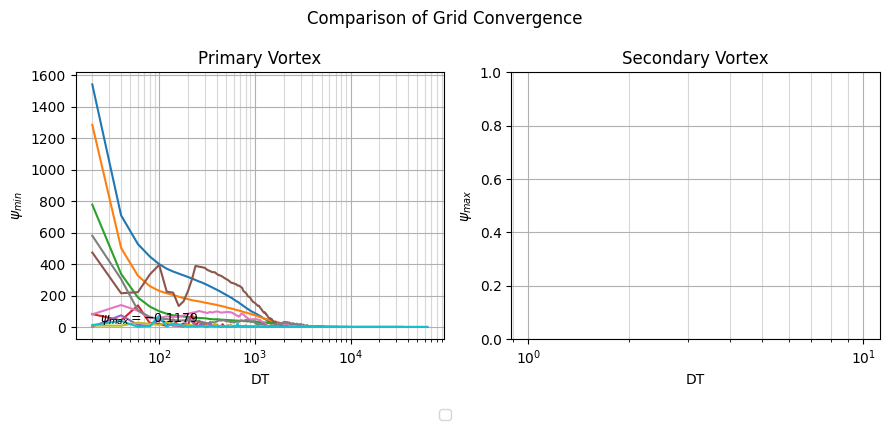

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
uds_primary = manager.collect_vortex_strengths()
labels = ["EFSM UDS","EFSM QUICk"]


for group,label in zip(groups, labels):
    for case_id, case in group.compare_convergence().groupby("case"):
        axes[0].plot(case["IT"], case["N"])
    primary, secondary = group.collect_vortex_strengths()
    compare_time_df = group.compare_time()

    psi_min = primary["psi"]
    psi_max = secondary["psi"]
    ms,lw =5, 1
    # axes[0].plot(compare_time_df["DT"],compare_time_df["psi_min"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
    # axes[1].plot(compare_time_df["DT"], compare_time_df["psi_min"], linestyle='-', marker='o', label=label, linewidth=lw, markersize=ms)
ghia = [-0.117929, 0.00175102]
for ax, title, y_label,ref_psi in zip(axes, ["Primary Vortex", "Secondary Vortex"], [r"$\psi_{min}$", r"$\psi_{max}$"], ghia):
     ax.set_title(title)      
     ax.set_xlabel("DT")
     ax.grid(which='major')
     ax.grid(which='minor', alpha=0.5)
     ax.set_ylabel(y_label)
    #  ax.axhline(y=ref_psi, color='black', linestyle='--', label='Ghia et al.',zorder=0)
     ax.annotate(rf'$\psi_{{max}}={ref_psi:.4f}$', 
                    xy=(254, ref_psi+0.01*abs(ref_psi)), ha='right', va='bottom',
                    fontsize=9,
                    color='black')
     ax.set_xscale('log')

fig.suptitle("Comparison of Grid Convergence")
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend( handles,labels,ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0))